## Machine Learning Lab — Week 01
### 23-NTU-CS-FL-1254
### Haider Ali

## 1. Machine Learning Workflow

The workflow followed in the lab is:

1. Load the dataset  
2. Preprocess the dataset  
3. Analyze / explore the dataset  
4. Apply a learning scheme or algorithm  
5. Generate a model and make predictions  
6. Evaluate the model

## 2. Environment Setup

In [49]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

DATA_DIR = Path("Data sets")

print("Environment ready.")
print("Expected dataset folder:", DATA_DIR)

Environment ready.
Expected dataset folder: Data sets


## 3. Loading the Dataset

### 3.1 Manual DataFrame Creation

In [50]:
manual_df = pd.DataFrame({
    "Name": ["Alice", "Bob", "Charlie", "Diana"],
    "Age": [25, 30, 35, 28],
    "City": ["Lahore", "Faisalabad", "Karachi", "Multan"],
    "Salary": [50000, 60000, 70000, 55000]
})

print("Manual DataFrame:")
display(manual_df)

Manual DataFrame:


,Name,Age,City,Salary
0,Alice,25,Lahore,50000
1,Bob,30,Faisalabad,60000
2,Charlie,35,Karachi,70000
3,Diana,28,Multan,55000


### 3.2 Loading from a CSV File

In [51]:
cars_path = DATA_DIR / "cars.csv"

if cars_path.exists():
    cars_df = pd.read_csv(cars_path)
    print("CSV Data:")
    display(cars_df.head())
else:
    print(f"Place cars.csv inside: {DATA_DIR.resolve()}")

CSV Data:


,Car,Model,Volume,Weight,CO2
0,Toyoty,Aygo,1000,790,99
1,Mitsubishi,Space Star,1200,1160,95
2,Skoda,Citigo,1000,929,95
3,Fiat,500,900,865,90
4,Mini,Cooper,1500,1140,105


### 3.3 Loading from a JSON File

In [52]:
json_path = DATA_DIR / "attendance.json"

if json_path.exists():
    attendance_df = pd.read_json(json_path)
    print("JSON Data:")
    display(attendance_df.head())
else:
    print(f"Place attendance.json inside: {DATA_DIR.resolve()}")

JSON Data:


,Name,Attendance
0,Student_1,86
1,Student_2,56
2,Student_3,70
3,Student_4,58
4,Student_5,88


### 3.4 Loading from an Excel File

In [53]:
excel_path = DATA_DIR / "extra.xlsx"

if excel_path.exists():
    extra_df = pd.read_excel(excel_path)
    print("Excel Data:")
    display(extra_df.head())
else:
    print(f"Place extra.xlsx inside: {DATA_DIR.resolve()}")

Excel Data:


,Name,Bonus
0,Student_1,4
1,Student_2,7
2,Student_3,9
3,Student_4,8
4,Student_5,8


### 3.5 Loading from a Text File

In [54]:
text_path = DATA_DIR / "data.txt"

if text_path.exists():
    text_df = pd.read_csv(text_path, sep="\t")
    print("Text File Data:")
    display(text_df)
else:
    print(f"Place data.txt inside: {DATA_DIR.resolve()}")

Text File Data:


,Name,Age,City
0,Ali,24,Lahore
1,Sara,29,Karachi
2,Ahmed,31,Islamabad
3,Zara,27,Multan


### 3.6 Creating Sample Data with NumPy

In [55]:
np.random.seed(42)

numpy_df = pd.DataFrame({
    "ID": np.arange(1, 6),
    "Score": np.random.randint(50, 100, 5),
    "Height": np.round(np.random.uniform(150, 180, 5), 1),
    "Weight": np.round(np.random.uniform(55, 80, 5), 1)
})

print("NumPy Generated Data:")
display(numpy_df)

NumPy Generated Data:


,ID,Score,Height,Weight
0,1,88,168.0,70.0
1,2,78,154.7,72.7
2,3,64,154.7,55.5
3,4,92,151.7,79.2
4,5,57,176.0,75.8


### 3.7 Loading a Built-in Dataset with Scikit-learn

In [56]:
iris = load_iris()

X = iris.data
y = iris.target

print("Features (first 5 rows):")
print(X[:5])

print("\nTarget values (first 5):")
print(y[:5])

Features (first 5 rows):
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Target values (first 5):
[0 0 0 0 0]


## 4. Data Preprocessing

### 4.1 Handling Missing Values

Three common approaches demonstrated in the lab are:

- Drop rows containing missing values
- Drop columns containing missing values
- Fill missing values using a replacement such as mean, median, mode, or a constant

In [57]:
missing_df = pd.DataFrame({
    "A": [1.0, 2.0, np.nan, 4.0, 5.0],
    "B": [6.0, np.nan, 8.0, 9.0, 10.0],
    "C": [11.0, 12.0, 13.0, np.nan, 15.0]
})

print("Original DataFrame:")
display(missing_df)

print("DataFrame after dropping rows with missing values:")
display(missing_df.dropna())

print("DataFrame after dropping columns with missing values:")
display(missing_df.dropna(axis=1))

print("DataFrame after filling missing values with the median:")
display(missing_df.fillna(missing_df.median(numeric_only=True)))

Original DataFrame:


,A,B,C
0,1.0,6.0,11.0
1,2.0,NaN,12.0
2,NaN,8.0,13.0
3,4.0,9.0,NaN
4,5.0,10.0,15.0


DataFrame after dropping rows with missing values:


,A,B,C
0,1.0,6.0,11.0
4,5.0,10.0,15.0


DataFrame after dropping columns with missing values:


""
0
1
2
3
4


DataFrame after filling missing values with the median:


,A,B,C
0,1.0,6.0,11.0
1,2.0,8.5,12.0
2,3.0,8.0,13.0
3,4.0,9.0,12.5
4,5.0,10.0,15.0


### 4.2 Handling Categorical Values

#### A. Manual / Ordinal Mapping

In [58]:
type_series = pd.Series(["Type1", "Type1", "Type3"], name="Type")

manual_mapping = {
    "Type1": 2,
    "Type2": 3,
    "Type3": 1
}

encoded_types = type_series.map(manual_mapping)

print("Encoded Types:")
display(encoded_types)

Encoded Types:


0    2
1    2
2    1
Name: Type, dtype: int64

#### B. Label Encoding

In [59]:
regions = pd.DataFrame({
    "Region": ["North", "East", "South", "West", "North", "East"]
})

label_encoder = LabelEncoder()
regions["Region_Encoded"] = label_encoder.fit_transform(regions["Region"])

print("Label Encoded Regions:")
display(regions)

print("Mapping:")
for class_name, encoded_value in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"{class_name:>6} -> {encoded_value}")

Label Encoded Regions:


,Region,Region_Encoded
0,North,1
1,East,0
2,South,2
3,West,3
4,North,1
5,East,0


Mapping:
  East -> 0
 North -> 1
 South -> 2
  West -> 3


#### C. One-Hot Encoding

In [60]:
methods = pd.DataFrame({
    "Method": ["Method2", "Method1", "Method3", "Method2"]
})

one_hot = pd.get_dummies(methods["Method"])

print("One-Hot Encoded DataFrame:")
display(one_hot)

One-Hot Encoded DataFrame:


,Method1,Method2,Method3
0,False,True,False
1,True,False,False
2,False,False,True
3,False,True,False


#### D. Ordered Categories with `OrdinalEncoder`

In [61]:
education_df = pd.DataFrame({
    "Education": ["High School", "Bachelors", "Masters", "PhD", "Bachelors"]
})

order = [["High School", "Bachelors", "Masters", "PhD"]]

ordinal_encoder = OrdinalEncoder(categories=order)
education_df["Education_Encoded"] = ordinal_encoder.fit_transform(
    education_df[["Education"]]
)

display(education_df)

,Education,Education_Encoded
0,High School,0.0
1,Bachelors,1.0
2,Masters,2.0
3,PhD,3.0
4,Bachelors,1.0


### 4.3 Handling Outliers

#### A. Boxplot Visualization

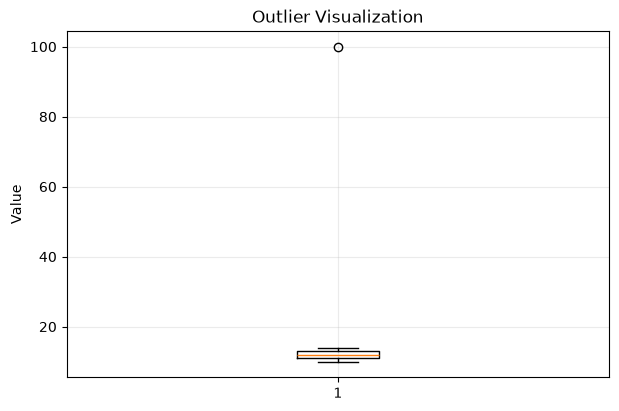

In [62]:
outlier_values = [10, 11, 12, 13, 12, 14, 13, 11, 100]

plt.figure()
plt.boxplot(outlier_values)
plt.title("Outlier Visualization")
plt.ylabel("Value")
plt.show()

#### B. IQR Method

In [63]:
income_df = pd.DataFrame({
    "Income": [25000, 27000, 26000, 28000, 500000, 24000]
})

Q1 = income_df["Income"].quantile(0.25)
Q3 = income_df["Income"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = income_df[
    (income_df["Income"] < lower_limit) |
    (income_df["Income"] > upper_limit)
]

cleaned_income = income_df[
    (income_df["Income"] >= lower_limit) &
    (income_df["Income"] <= upper_limit)
]

print("Detected outlier(s):")
display(outliers)

print("Cleaned data:")
display(cleaned_income)

Detected outlier(s):


,Income
4,500000


Cleaned data:


,Income
0,25000
1,27000
2,26000
3,28000
5,24000


#### C. Log Transformation

In [64]:
income_log_df = income_df.copy()
income_log_df["Income_Log"] = np.log(income_log_df["Income"])

display(income_log_df)

,Income,Income_Log
0,25000,10.126631
1,27000,10.203592
2,26000,10.165852
3,28000,10.239960
4,500000,13.122363
5,24000,10.085809


### 4.4 Feature Scaling

In [65]:
scale_df = pd.DataFrame({
    "Age": [22, 25, 47, 35, 60],
    "Income": [25000, 32000, 95000, 60000, 150000]
})

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

data_standard = standard_scaler.fit_transform(scale_df)
data_minmax = minmax_scaler.fit_transform(scale_df)
data_robust = robust_scaler.fit_transform(scale_df)

print("Standardized data:")
print(data_standard)

print("\nMin-Max scaled data:")
print(data_minmax)

print("\nRobust-scaled data:")
print(data_robust)

Standardized data:
[[-1.11789966 -1.03115626]
 [-0.90564023 -0.8788758 ]
 [ 0.65092891  0.49164834]
 [-0.1981088  -0.26975396]
 [ 1.57071977  1.68813767]]

Min-Max scaled data:
[[0.         0.        ]
 [0.07894737 0.056     ]
 [0.65789474 0.56      ]
 [0.34210526 0.28      ]
 [1.         1.        ]]

Robust-scaled data:
[[-0.59090909 -0.55555556]
 [-0.45454545 -0.44444444]
 [ 0.54545455  0.55555556]
 [ 0.          0.        ]
 [ 1.13636364  1.42857143]]


### 4.5 Feature Selection, Feature Engineering, and PCA

In [66]:
feature_df = pd.DataFrame({
    "Height_cm": [150, 160, 170, 180, 190],
    "Height_inch": [59, 63, 67, 71, 75],
    "Weight": [50, 60, 70, 80, 90],
    "Date": ["2026-01-05", "2026-02-10", "2026-03-15", "2026-04-01", "2026-05-20"]
})

# 1. Feature Selection
correlation = feature_df[["Height_cm", "Height_inch", "Weight"]].corr()
print("Correlation Matrix:")
display(correlation)

feature_df = feature_df.drop("Height_inch", axis=1)

# 2. Feature Engineering
feature_df["BMI"] = feature_df["Weight"] / ((feature_df["Height_cm"] / 100) ** 2)
feature_df["Date"] = pd.to_datetime(feature_df["Date"])
feature_df["Day_of_Week"] = feature_df["Date"].dt.day_name()

print("Data after Feature Engineering:")
display(feature_df)

# 3. PCA
numeric_features = feature_df[["Height_cm", "Weight", "BMI"]]
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(numeric_features)

print("Data after PCA (2 components):")
print(reduced_data)

Correlation Matrix:


,Height_cm,Height_inch,Weight
Height_cm,1.0,1.0,1.0
Height_inch,1.0,1.0,1.0
Weight,1.0,1.0,1.0


Data after Feature Engineering:


,Height_cm,Weight,Date,BMI,Day_of_Week
0,150,50,2026-01-05,22.222222,Monday
1,160,60,2026-02-10,23.437500,Tuesday
2,170,70,2026-03-15,24.221453,Sunday
3,180,80,2026-04-01,24.691358,Wednesday
4,190,90,2026-05-20,24.930748,Wednesday


Data after PCA (2 components):
[[-2.83319442e+01 -3.43623138e-01]
 [-1.41482496e+01  2.03831339e-01]
 [ 1.51181229e-02  3.20440564e-01]
 [ 1.41636857e+01  1.23350173e-01]
 [ 2.83013900e+01 -3.03998937e-01]]


### 4.6 Handling Imbalanced Data

In [67]:
# This cell follows the lab example.
# imbalanced-learn may need to be installed once:
# !pip install imbalanced-learn

try:
    from sklearn.model_selection import train_test_split
    from sklearn.linear_model import LogisticRegression
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler

    np.random.seed(42)

    X_imb = pd.DataFrame({
        "Feature1": np.random.rand(1000),
        "Feature2": np.random.rand(1000)
    })
    y_imb = pd.Series([0] * 900 + [1] * 100)

    print("Original class distribution:")
    display(y_imb.value_counts().sort_index())

    X_train, X_test, y_train, y_test = train_test_split(
        X_imb, y_imb,
        test_size=0.2,
        random_state=42,
        stratify=y_imb
    )

    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    print("After SMOTE:")
    display(y_train_smote.value_counts().sort_index())

    undersampler = RandomUnderSampler(random_state=42)
    X_train_under, y_train_under = undersampler.fit_resample(X_train, y_train)

    print("After undersampling:")
    display(y_train_under.value_counts().sort_index())

    model = LogisticRegression(class_weight="balanced")
    model.fit(X_train, y_train)

    print("Class-weighted model trained successfully.")
except ImportError:
    print("Install imbalanced-learn to run this section: pip install imbalanced-learn")

Original class distribution:


0    900
1    100
Name: count, dtype: int64

After SMOTE:


0    720
1    720
Name: count, dtype: int64

After undersampling:


0    80
1    80
Name: count, dtype: int64

Class-weighted model trained successfully.


## 5. Data Visualization

### 5.1 Line Plot

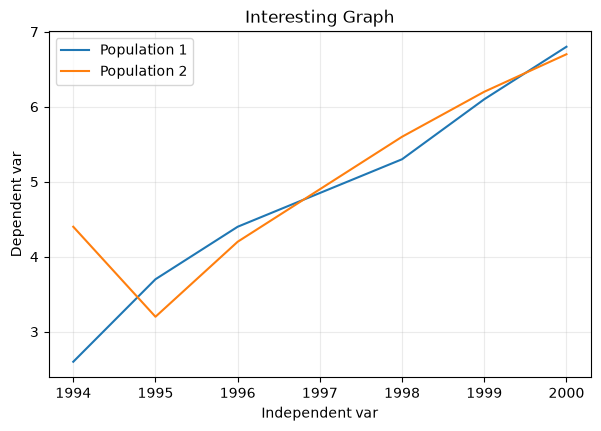

In [68]:
years = np.array([1994, 1995, 1996, 1998, 1999, 2000])
population_1 = np.array([2.6, 3.7, 4.4, 5.3, 6.1, 6.8])
population_2 = np.array([4.4, 3.2, 4.2, 5.6, 6.2, 6.7])

plt.figure()
plt.plot(years, population_1, label="Population 1")
plt.plot(years, population_2, label="Population 2")
plt.title("Interesting Graph")
plt.xlabel("Independent var")
plt.ylabel("Dependent var")
plt.legend()
plt.show()

### 5.2 Filled Area Plot

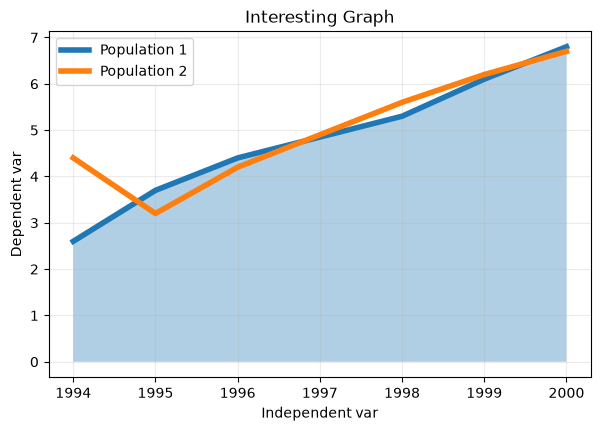

In [69]:
plt.figure()
plt.plot(years, population_1, linewidth=4, label="Population 1")
plt.plot(years, population_2, linewidth=4, label="Population 2")
plt.fill_between(years, population_1, alpha=0.35)
plt.title("Interesting Graph")
plt.xlabel("Independent var")
plt.ylabel("Dependent var")
plt.legend()
plt.show()

### 5.3 Histogram

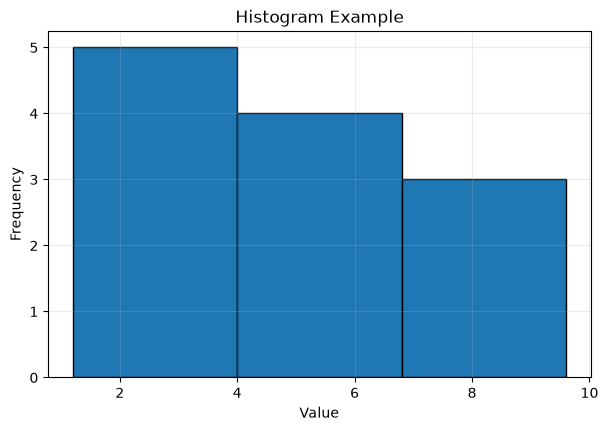

In [70]:
values = [1.2, 1.8, 2.4, 2.8, 3.5, 4.5, 5.2, 5.8, 6.6, 7.2, 8.4, 9.6]

plt.figure()
plt.hist(values, bins=3, edgecolor="black")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram Example")
plt.show()

## 6. Exploring Datasets

### 6.1 Iris Dataset Exploration

In [71]:
iris = load_iris()

print("Keys:")
print(iris.keys())

print("\nTarget names:")
print(iris["target_names"])

n_samples, n_features = iris.data.shape

print("\nNumber of samples:", n_samples)
print("Number of features:", n_features)
print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)
print("Dimension of input:", iris.data.shape)
print("Dimension of output:", iris.target.shape)

print("\nFirst 5 rows of input:")
print(iris.data[:5])

print("\nTarget data:")
print(iris.target)

Keys:
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

Target names:
['setosa' 'versicolor' 'virginica']

Number of samples: 150
Number of features: 4
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Dimension of input: (150, 4)
Dimension of output: (150,)

First 5 rows of input:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Target data:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


### 6.2 Olivetti Faces Dataset Exploration

Data shape: (400, 4096)
Images shape: (400, 64, 64)
Target shape: (400,)


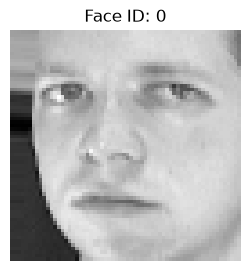

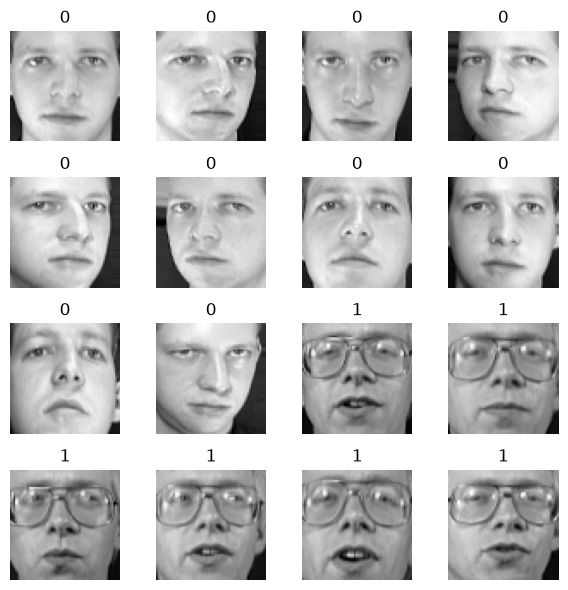

In [72]:
# The Olivetti dataset may download the first time it is used.
try:
    from sklearn.datasets import fetch_olivetti_faces

    faces = fetch_olivetti_faces(shuffle=False)
    X_faces, y_faces = faces.data, faces.target

    print("Data shape:", faces.data.shape)
    print("Images shape:", faces.images.shape)
    print("Target shape:", faces.target.shape)

    # Show one image
    plt.figure(figsize=(3, 3))
    plt.imshow(faces.images[5], cmap="gray")
    plt.title(f"Face ID: {faces.target[5]}")
    plt.axis("off")
    plt.show()

    # Show first 16 images
    plt.figure(figsize=(6, 6))
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(faces.images[i], cmap="gray")
        plt.axis("off")
        plt.title(str(faces.target[i]))
    plt.tight_layout()
    plt.show()

except Exception as exc:
    print("Olivetti Faces could not be loaded in this environment.")
    print("Run this cell on a machine with internet access the first time.")
    print("Reason:", exc)

# 7. Lab Activities

## Activity 1 — Pakistani Provinces Analysis

<div class="taskbox">
Create a dataset of 4 provinces of Pakistan with columns:
<b>Province, Population (millions), Literacy Rate (%), Region (North, South, East, West)</b>.

Tasks:
- Handle missing values: drop one row and fill another missing value with the median.
- Encode <code>Region</code> using Label Encoding and One-Hot Encoding.
- Plot Population vs Literacy Rate and label each province.
- Detect whether any province behaves like an outlier in literacy rate.
</div>

Original Dataset:


,Province,Population (millions),Literacy Rate (%),Region
0,Punjab,127.7,66.0,East
1,Sindh,NaN,58.0,South
2,Khyber Pakhtunkhwa,40.9,NaN,North
3,Balochistan,14.9,20.0,West


After filling missing Literacy Rate with median:


,Province,Population (millions),Literacy Rate (%),Region
0,Punjab,127.7,66.0,East
1,Sindh,NaN,58.0,South
2,Khyber Pakhtunkhwa,40.9,58.0,North
3,Balochistan,14.9,20.0,West


After dropping row with missing Population:


,Province,Population (millions),Literacy Rate (%),Region
0,Punjab,127.7,66.0,East
1,Khyber Pakhtunkhwa,40.9,58.0,North
2,Balochistan,14.9,20.0,West


After Label Encoding:


,Province,Population (millions),Literacy Rate (%),Region,Region_Label
0,Punjab,127.7,66.0,East,0
1,Khyber Pakhtunkhwa,40.9,58.0,North,1
2,Balochistan,14.9,20.0,West,2


Region Encoding:
East -> 0
North -> 1
West -> 2
After One-Hot Encoding:


,Province,Population (millions),Literacy Rate (%),Region,Region_Label,Region_East,Region_North,Region_West
0,Punjab,127.7,66.0,East,0,1,0,0
1,Khyber Pakhtunkhwa,40.9,58.0,North,1,0,1,0
2,Balochistan,14.9,20.0,West,2,0,0,1


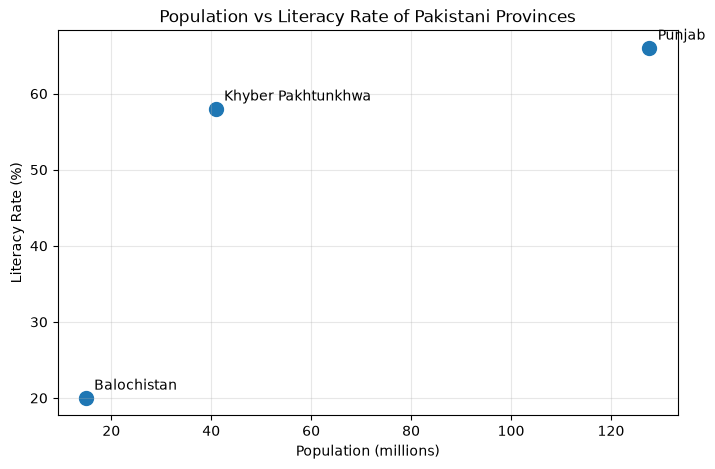

Q1: 39.0
Q3: 62.0
IQR: 23.0
Lower Limit: 4.5
Upper Limit: 96.5

Outliers:
No province is detected as an outlier in Literacy Rate.


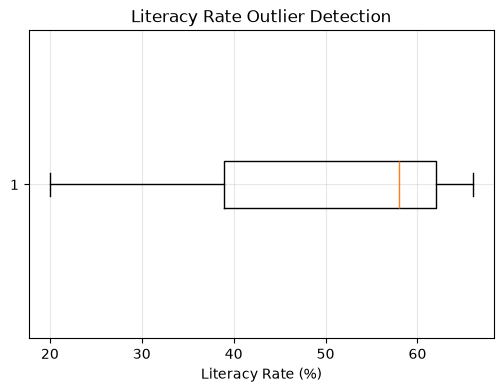

In [73]:
# Activity 1: Pakistani Provinces Analysis
# ---------------------------------------------------------
# 1. Create dataset
# ---------------------------------------------------------

data = {
    "Province": ["Punjab", "Sindh", "Khyber Pakhtunkhwa", "Balochistan"],
    "Population (millions)": [127.7, np.nan, 40.9, 14.9],
    "Literacy Rate (%)": [66, 58, np.nan, 20],
    "Region": ["East", "South", "North", "West"]
}

df = pd.DataFrame(data)

print("Original Dataset:")
display(df)


# ---------------------------------------------------------
# 2. Handle missing values
#    - Fill one missing value with median
#    - Drop one row containing a missing value
# ---------------------------------------------------------

literacy_median = df["Literacy Rate (%)"].median()

df["Literacy Rate (%)"] = df["Literacy Rate (%)"].fillna(literacy_median)

print("After filling missing Literacy Rate with median:")
display(df)

# Drop the row where Population is missing
df = df.dropna(subset=["Population (millions)"]).reset_index(drop=True)

print("After dropping row with missing Population:")
display(df)


# ---------------------------------------------------------
# 3. Label Encoding for Region
# ---------------------------------------------------------

label_encoder = LabelEncoder()

df["Region_Label"] = label_encoder.fit_transform(df["Region"])

print("After Label Encoding:")
display(df)

print("Region Encoding:")
for region, code in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(f"{region} -> {code}")


# ---------------------------------------------------------
# 4. One-Hot Encoding for Region
# ---------------------------------------------------------

region_one_hot = pd.get_dummies(
    df["Region"],
    prefix="Region",
    dtype=int
)

df_encoded = pd.concat([df, region_one_hot], axis=1)

print("After One-Hot Encoding:")
display(df_encoded)


# ---------------------------------------------------------
# 5. Scatter Plot: Population vs Literacy Rate
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Population (millions)"],
    df["Literacy Rate (%)"],
    s=100
)

for i in range(len(df)):
    plt.annotate(
        df.loc[i, "Province"],
        (
            df.loc[i, "Population (millions)"],
            df.loc[i, "Literacy Rate (%)"]
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.title("Population vs Literacy Rate of Pakistani Provinces")
plt.xlabel("Population (millions)")
plt.ylabel("Literacy Rate (%)")
plt.grid(alpha=0.3)
plt.show()


# ---------------------------------------------------------
# 6. Detect Outliers in Literacy Rate using IQR
# ---------------------------------------------------------

Q1 = df["Literacy Rate (%)"].quantile(0.25)
Q3 = df["Literacy Rate (%)"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["Literacy Rate (%)"] < lower_limit) |
    (df["Literacy Rate (%)"] > upper_limit)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

print("\nOutliers:")
if outliers.empty:
    print("No province is detected as an outlier in Literacy Rate.")
else:
    display(outliers[["Province", "Literacy Rate (%)"]])


# ---------------------------------------------------------
# 7. Boxplot for Literacy Rate
# ---------------------------------------------------------

plt.figure(figsize=(6, 4))

plt.boxplot(
    df["Literacy Rate (%)"],
    vert=False
)

plt.title("Literacy Rate Outlier Detection")
plt.xlabel("Literacy Rate (%)")
plt.grid(alpha=0.3)

plt.show()

## Activity 2 — Student Performance Tracker

Generate random data for 100 students with:
<b>ID, Math, Science, English, Grade (A/B/C)</b>.

Tasks:
- Fill missing marks using the mean.
- Encode Grade.
- Plot a 10-bin histogram of Math scores.
- Use a boxplot to detect unusually high / low total scores.
- Summarize which grade performed best overall.


Original Dataset:


,ID,Math,Science,English,Grade
0,1,67.0,60.0,46.0,C
1,2,46.0,44.0,55.0,B
2,3,74.0,41.0,42.0,B
3,4,94.0,61.0,84.0,C
4,5,67.0,87.0,42.0,A
5,6,NaN,96.0,66.0,C
6,7,95.0,41.0,89.0,B
7,8,49.0,49.0,82.0,A
8,9,55.0,73.0,79.0,A
9,10,55.0,55.0,77.0,C


Missing Values After Filling:
ID         0
Math       0
Science    0
English    0
Grade      0
dtype: int64

Grade Encoding:
A -> 0
B -> 1
C -> 2


,ID,Math,Science,English,Grade,Grade_Encoded
0,1,67.0,60.0,46.0,C,2
1,2,46.0,44.0,55.0,B,1
2,3,74.0,41.0,42.0,B,1
3,4,94.0,61.0,84.0,C,2
4,5,67.0,87.0,42.0,A,0


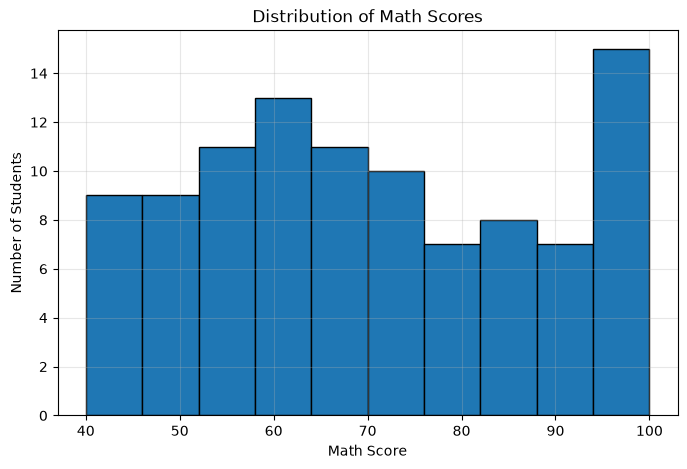

,ID,Math,Science,English,Grade,Grade_Encoded,Total
0,1,67.0,60.0,46.0,C,2,173.0
1,2,46.0,44.0,55.0,B,1,145.0
2,3,74.0,41.0,42.0,B,1,157.0
3,4,94.0,61.0,84.0,C,2,239.0
4,5,67.0,87.0,42.0,A,0,196.0


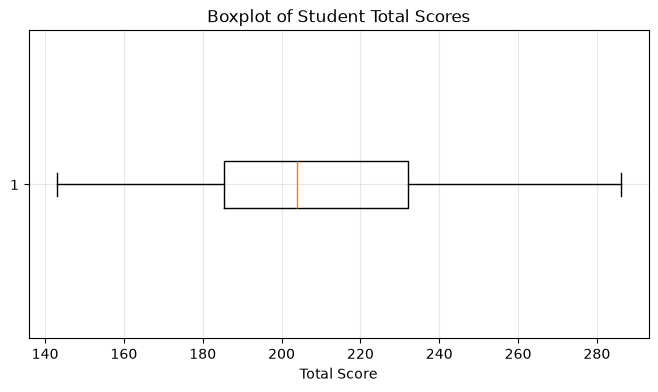

Lower Limit: 115.66494845360826
Upper Limit: 301.89175257731955

Students with unusually high/low scores:
No outliers found.

Average Total Score by Grade:


Grade
C    216.113820
A    205.376364
B    201.869728
Name: Total, dtype: float64

Best performing grade overall: Grade C


In [74]:
# Activity 2: Student Performance Tracker
# ---------------------------------------------------------
# 1. Generate random data for 100 students
# ---------------------------------------------------------

df = pd.DataFrame({
    "ID": range(1, 101),
    "Math": np.random.randint(40, 101, 100).astype(float),
    "Science": np.random.randint(40, 101, 100).astype(float),
    "English": np.random.randint(40, 101, 100).astype(float),
    "Grade": np.random.choice(["A", "B", "C"], 100)
})

# Introduce some missing marks
df.loc[[5, 20, 45], "Math"] = np.nan
df.loc[[10, 35], "Science"] = np.nan
df.loc[[15, 70], "English"] = np.nan

print("Original Dataset:")
display(df.head(10))


# ---------------------------------------------------------
# 2. Fill missing marks with mean
# ---------------------------------------------------------

for column in ["Math", "Science", "English"]:
    df[column] = df[column].fillna(df[column].mean())

print("Missing Values After Filling:")
print(df.isnull().sum())


# ---------------------------------------------------------
# 3. Encode Grade
# ---------------------------------------------------------

encoder = LabelEncoder()

df["Grade_Encoded"] = encoder.fit_transform(df["Grade"])

print("\nGrade Encoding:")
for grade, value in zip(
    encoder.classes_,
    encoder.transform(encoder.classes_)
):
    print(f"{grade} -> {value}")

display(df.head())


# ---------------------------------------------------------
# 4. Histogram of Math scores
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    df["Math"],
    bins=10,
    edgecolor="black"
)

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Number of Students")
plt.grid(alpha=0.3)

plt.show()


# ---------------------------------------------------------
# 5. Calculate total score
# ---------------------------------------------------------

df["Total"] = (
    df["Math"] +
    df["Science"] +
    df["English"]
)

display(df.head())


# ---------------------------------------------------------
# 6. Boxplot of total score
# ---------------------------------------------------------

plt.figure(figsize=(8, 4))

plt.boxplot(
    df["Total"],
    vert=False
)

plt.title("Boxplot of Student Total Scores")
plt.xlabel("Total Score")
plt.grid(alpha=0.3)

plt.show()


# ---------------------------------------------------------
# 7. Detect unusually high / low total scores using IQR
# ---------------------------------------------------------

Q1 = df["Total"].quantile(0.25)
Q3 = df["Total"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["Total"] < lower_limit) |
    (df["Total"] > upper_limit)
]

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

print("\nStudents with unusually high/low scores:")

if outliers.empty:
    print("No outliers found.")
else:
    display(
        outliers[
            ["ID", "Math", "Science", "English", "Grade", "Total"]
        ]
    )


# ---------------------------------------------------------
# 8. Find which grade performed best overall
# ---------------------------------------------------------

grade_performance = (
    df.groupby("Grade")["Total"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage Total Score by Grade:")
display(grade_performance)

best_grade = grade_performance.idxmax()

print(f"Best performing grade overall: Grade {best_grade}")

## Activity 3 — COVID-19 Dataset Exploration

Dataset URL given in the lab:

`https://raw.githubusercontent.com/datasets/covid-19/master/data/time-series-19-covid-combined.csv`

<div class="taskbox">
Tasks:
- Extract only Pakistan's data.
- Handle missing values properly.
- Plot confirmed cases over time.
- Find the day with the highest confirmed cases.
- Detect outliers in daily cases using a boxplot.
</div>

Original Dataset:


,Date,Country/Region,Province/State,Confirmed,Recovered,Deaths
0,2020-01-22,Afghanistan,NaN,0,0.0,0
1,2020-01-23,Afghanistan,NaN,0,0.0,0
2,2020-01-24,Afghanistan,NaN,0,0.0,0
3,2020-01-25,Afghanistan,NaN,0,0.0,0
4,2020-01-26,Afghanistan,NaN,0,0.0,0


Pakistan Data:


,Date,Country/Region,Province/State,Confirmed,Recovered,Deaths
168912,2020-01-22,Pakistan,NaN,0,0.0,0
168913,2020-01-23,Pakistan,NaN,0,0.0,0
168914,2020-01-24,Pakistan,NaN,0,0.0,0
168915,2020-01-25,Pakistan,NaN,0,0.0,0
168916,2020-01-26,Pakistan,NaN,0,0.0,0


Missing Values:
Date                0
Country/Region      0
Province/State    816
Confirmed           0
Recovered           0
Deaths              0
dtype: int64

Missing Values After Handling:
Date              0
Country/Region    0
Province/State    0
Confirmed         0
Recovered         0
Deaths            0
dtype: int64


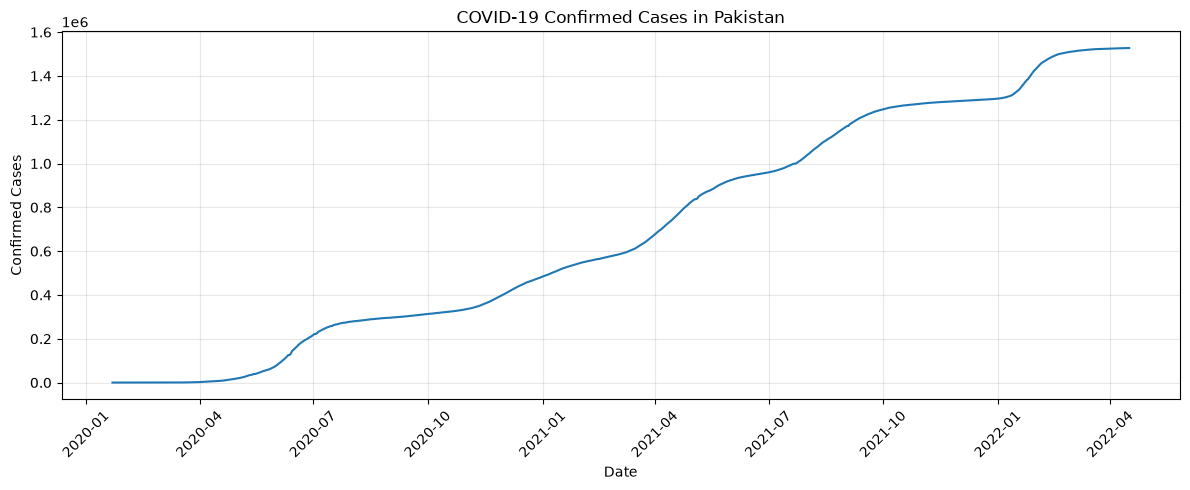

Day with Highest Confirmed Cases:
Date: 2022-04-16 00:00:00
Confirmed Cases: 1527248

Daily Cases:


,Date,Confirmed,Daily_Cases
168912,2020-01-22,0,0.0
168913,2020-01-23,0,0.0
168914,2020-01-24,0,0.0
168915,2020-01-25,0,0.0
168916,2020-01-26,0,0.0


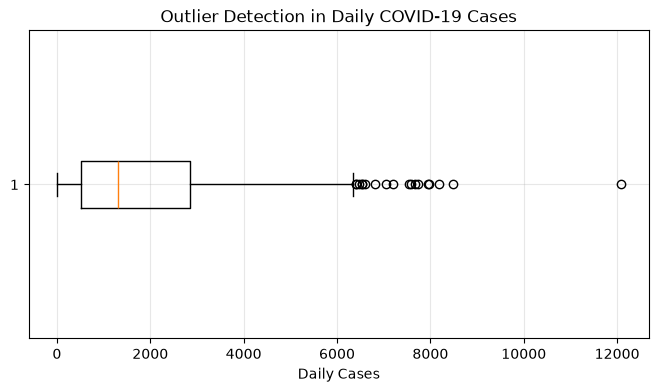

Daily Case Outliers:


,Date,Confirmed,Daily_Cases
169053,2020-06-11,125933,6397.0
169055,2020-06-13,132405,6472.0
169056,2020-06-14,144478,12073.0
169061,2020-06-19,171666,6604.0
169077,2020-07-05,231818,6535.0
169382,2021-05-06,850131,8495.0
169503,2021-09-04,1179305,7727.0
169640,2022-01-19,1345801,6808.0
169641,2022-01-20,1353479,7678.0
169642,2022-01-21,1360019,6540.0


In [75]:
# Activity 3: COVID-19 Dataset Exploration
# ---------------------------------------------------------
# 1. Load online COVID-19 dataset
# ---------------------------------------------------------

url = (
    "https://raw.githubusercontent.com/datasets/covid-19/"
    "master/data/time-series-19-covid-combined.csv"
)

df = pd.read_csv(url)

print("Original Dataset:")
display(df.head())


# ---------------------------------------------------------
# 2. Extract Pakistan's data
# ---------------------------------------------------------

pakistan = df[
    df["Country/Region"] == "Pakistan"
].copy()

print("Pakistan Data:")
display(pakistan.head())


# ---------------------------------------------------------
# 3. Handle missing values
# ---------------------------------------------------------

print("Missing Values:")
print(pakistan.isnull().sum())

# Province/State is normally missing for country-level records.
# Fill it with Pakistan.
pakistan["Province/State"] = (
    pakistan["Province/State"]
    .fillna("Pakistan")
)

# Fill missing numeric values with 0 if any
numeric_columns = [
    "Confirmed",
    "Recovered",
    "Deaths"
]

for column in numeric_columns:
    if column in pakistan.columns:
        pakistan[column] = pakistan[column].fillna(0)

print("\nMissing Values After Handling:")
print(pakistan.isnull().sum())


# ---------------------------------------------------------
# 4. Convert Date to datetime
# ---------------------------------------------------------

pakistan["Date"] = pd.to_datetime(
    pakistan["Date"]
)

pakistan = pakistan.sort_values("Date")


# ---------------------------------------------------------
# 5. Plot confirmed cases over time
# ---------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    pakistan["Date"],
    pakistan["Confirmed"]
)

plt.title("COVID-19 Confirmed Cases in Pakistan")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


# ---------------------------------------------------------
# 6. Find the day with highest confirmed cases
# ---------------------------------------------------------

highest_row = pakistan.loc[
    pakistan["Confirmed"].idxmax()
]

print("Day with Highest Confirmed Cases:")
print("Date:", highest_row["Date"])
print("Confirmed Cases:", highest_row["Confirmed"])


# ---------------------------------------------------------
# 7. Calculate daily new confirmed cases
# ---------------------------------------------------------

pakistan["Daily_Cases"] = (
    pakistan["Confirmed"]
    .diff()
    .fillna(0)
)

# Negative corrections should not be interpreted as new cases
# for this simple lab analysis.
print("\nDaily Cases:")
display(
    pakistan[
        ["Date", "Confirmed", "Daily_Cases"]
    ].head()
)


# ---------------------------------------------------------
# 8. Boxplot of daily cases
# ---------------------------------------------------------

plt.figure(figsize=(8, 4))

plt.boxplot(
    pakistan["Daily_Cases"],
    vert=False
)

plt.title("Outlier Detection in Daily COVID-19 Cases")
plt.xlabel("Daily Cases")
plt.grid(alpha=0.3)

plt.show()


# ---------------------------------------------------------
# 9. Detect daily-case outliers using IQR
# ---------------------------------------------------------

Q1 = pakistan["Daily_Cases"].quantile(0.25)
Q3 = pakistan["Daily_Cases"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

daily_outliers = pakistan[
    (pakistan["Daily_Cases"] < lower_limit) |
    (pakistan["Daily_Cases"] > upper_limit)
]

print("Daily Case Outliers:")
display(
    daily_outliers[
        ["Date", "Confirmed", "Daily_Cases"]
    ]
)

## Activity 4 — Multi-format Data Loading & Visualization Challenge

Files provided:
- `students.csv`
- `attendance.json`
- `extra.xlsx`

<div class="taskbox">
Tasks:
- Load all three files into Pandas DataFrames.
- Merge them into columns: <b>Name, Marks, Attendance, Bonus</b>.
- Plot Marks vs Attendance and highlight attendance below 70%.
- Apply one-hot encoding on Name.
</div>

Students:


,Name,Marks
0,Student_1,78
1,Student_2,91
2,Student_3,68
3,Student_4,54
4,Student_5,82


Attendance:


,Name,Attendance
0,Student_1,86
1,Student_2,56
2,Student_3,70
3,Student_4,58
4,Student_5,88


Extra Marks:


,Name,Bonus
0,Student_1,4
1,Student_2,7
2,Student_3,9
3,Student_4,8
4,Student_5,8


Merged Dataset:


,Name,Marks,Attendance,Bonus
0,Student_1,78,86,4
1,Student_2,91,56,7
2,Student_3,68,70,9
3,Student_4,54,58,8
4,Student_5,82,88,8
5,Student_6,47,67,0
6,Student_7,60,53,8
7,Student_8,78,74,6
8,Student_9,97,63,8
9,Student_10,58,99,7


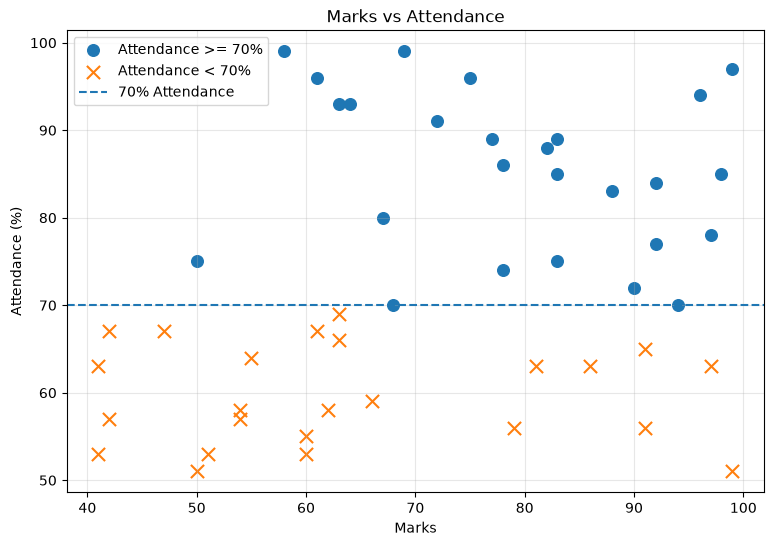

Students with Attendance Below 70%:


,Name,Marks,Attendance,Bonus
1,Student_2,91,56,7
3,Student_4,54,58,8
5,Student_6,47,67,0
6,Student_7,60,53,8
8,Student_9,97,63,8
10,Student_11,62,58,0
12,Student_13,50,51,7
13,Student_14,63,69,2
16,Student_17,79,56,2
18,Student_19,42,57,0


One-Hot Encoded Dataset:


,Name,Marks,Attendance,Bonus,Name_Student_1,Name_Student_10,Name_Student_11,Name_Student_12,Name_Student_13,Name_Student_14,...,Name_Student_46,Name_Student_47,Name_Student_48,Name_Student_49,Name_Student_5,Name_Student_50,Name_Student_6,Name_Student_7,Name_Student_8,Name_Student_9
0,Student_1,78,86,4,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Student_2,91,56,7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Student_3,68,70,9,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Student_4,54,58,8,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Student_5,82,88,8,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
5,Student_6,47,67,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
6,Student_7,60,53,8,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
7,Student_8,78,74,6,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
8,Student_9,97,63,8,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
9,Student_10,58,99,7,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [76]:
# Activity 4: Multi-format Data Loading & Visualization

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("Data sets")

# ---------------------------------------------------------
# 1. Load CSV, JSON and Excel files
# ---------------------------------------------------------

students = pd.read_csv(
    DATA_DIR / "students.csv"
)

attendance = pd.read_json(
    DATA_DIR / "attendance.json"
)

extra = pd.read_excel(
    DATA_DIR / "extra.xlsx"
)

print("Students:")
display(students.head())

print("Attendance:")
display(attendance.head())

print("Extra Marks:")
display(extra.head())


# ---------------------------------------------------------
# 2. Merge all three datasets
# ---------------------------------------------------------

merged_df = students.merge(
    attendance,
    on="Name",
    how="inner"
)

merged_df = merged_df.merge(
    extra,
    on="Name",
    how="inner"
)

print("Merged Dataset:")
display(merged_df)


# ---------------------------------------------------------
# 3. Scatter Plot: Marks vs Attendance
#    Highlight students with attendance < 70%
# ---------------------------------------------------------

normal_attendance = merged_df[
    merged_df["Attendance"] >= 70
]

low_attendance = merged_df[
    merged_df["Attendance"] < 70
]

plt.figure(figsize=(9, 6))

plt.scatter(
    normal_attendance["Marks"],
    normal_attendance["Attendance"],
    label="Attendance >= 70%",
    s=70
)

plt.scatter(
    low_attendance["Marks"],
    low_attendance["Attendance"],
    label="Attendance < 70%",
    marker="x",
    s=90
)

plt.axhline(
    y=70,
    linestyle="--",
    label="70% Attendance"
)

plt.title("Marks vs Attendance")
plt.xlabel("Marks")
plt.ylabel("Attendance (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ---------------------------------------------------------
# 4. Display students with attendance below 70%
# ---------------------------------------------------------

print("Students with Attendance Below 70%:")

display(
    low_attendance[
        ["Name", "Marks", "Attendance", "Bonus"]
    ]
)


# ---------------------------------------------------------
# 5. One-Hot Encode Name
# ---------------------------------------------------------

name_encoded = pd.get_dummies(
    merged_df["Name"],
    prefix="Name",
    dtype=int
)

encoded_df = pd.concat(
    [merged_df, name_encoded],
    axis=1
)

print("One-Hot Encoded Dataset:")
display(encoded_df)

## Activity 5 — Data Cleaning & Outlier Detection

Use this dataset:

```python
data = {
    "Name": ["Ahsan", "Hira", "Bilal", "Zara", "Salman", "Mahnoor"],
    "Age": [25, 27, 35, 29, None, 40],
    "Salary": [50000, None, 75000, 2000000, 60000, 90000],
    "Department": ["IT", "Finance", "IT", "HR", "Finance", "IT"]
}
```

<div class="taskbox">
Tasks:
- Handle missing values properly.
- Encode Department.
- Detect Salary outliers using a boxplot.
- Comment on whether Zara's salary should be treated as an outlier.
</div>

Original Dataset:


,Name,Age,Salary,Department
0,Ahsan,25.0,50000.0,IT
1,Hira,27.0,NaN,Finance
2,Bilal,35.0,75000.0,IT
3,Zara,29.0,2000000.0,HR
4,Salman,NaN,60000.0,Finance
5,Mahnoor,40.0,90000.0,IT


Dataset After Handling Missing Values:


,Name,Age,Salary,Department
0,Ahsan,25.0,50000.0,IT
1,Hira,27.0,75000.0,Finance
2,Bilal,35.0,75000.0,IT
3,Zara,29.0,2000000.0,HR
4,Salman,29.0,60000.0,Finance
5,Mahnoor,40.0,90000.0,IT



Missing Values:
Name          0
Age           0
Salary        0
Department    0
dtype: int64

Department Encoding:
Finance -> 0
HR -> 1
IT -> 2


,Name,Age,Salary,Department,Department_Encoded
0,Ahsan,25.0,50000.0,IT,2
1,Hira,27.0,75000.0,Finance,0
2,Bilal,35.0,75000.0,IT,2
3,Zara,29.0,2000000.0,HR,1
4,Salman,29.0,60000.0,Finance,0
5,Mahnoor,40.0,90000.0,IT,2


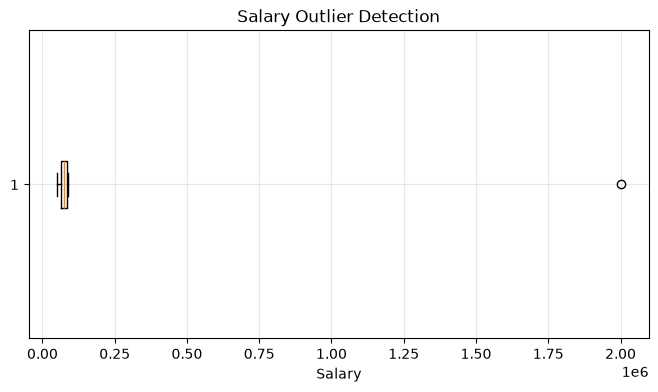

Q1: 63750.0
Q3: 86250.0
IQR: 22500.0
Lower Limit: 30000.0
Upper Limit: 120000.0

Salary Outliers:


,Name,Salary
3,Zara,2000000.0


Conclusion: Zara's salary is detected as an outlier by the IQR method because it is far above the upper limit.


In [77]:
# Activity 5: Data Cleaning & Outlier Detection

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# ---------------------------------------------------------
# 1. Create DataFrame
# ---------------------------------------------------------

data = {
    "Name": [
        "Ahsan",
        "Hira",
        "Bilal",
        "Zara",
        "Salman",
        "Mahnoor"
    ],

    "Age": [
        25,
        27,
        35,
        29,
        None,
        40
    ],

    "Salary": [
        50000,
        None,
        75000,
        2000000,
        60000,
        90000
    ],

    "Department": [
        "IT",
        "Finance",
        "IT",
        "HR",
        "Finance",
        "IT"
    ]
}

df = pd.DataFrame(data)

print("Original Dataset:")
display(df)


# ---------------------------------------------------------
# 2. Handle missing values
# ---------------------------------------------------------

df["Age"] = df["Age"].fillna(
    df["Age"].median()
)

df["Salary"] = df["Salary"].fillna(
    df["Salary"].median()
)

print("Dataset After Handling Missing Values:")
display(df)

print("\nMissing Values:")
print(df.isnull().sum())


# ---------------------------------------------------------
# 3. Encode Department
# ---------------------------------------------------------

encoder = LabelEncoder()

df["Department_Encoded"] = (
    encoder.fit_transform(df["Department"])
)

print("\nDepartment Encoding:")

for department, value in zip(
    encoder.classes_,
    encoder.transform(encoder.classes_)
):
    print(f"{department} -> {value}")

display(df)


# ---------------------------------------------------------
# 4. Salary boxplot
# ---------------------------------------------------------

plt.figure(figsize=(8, 4))

plt.boxplot(
    df["Salary"],
    vert=False
)

plt.title("Salary Outlier Detection")
plt.xlabel("Salary")
plt.grid(alpha=0.3)

plt.show()


# ---------------------------------------------------------
# 5. Detect Salary outliers using IQR
# ---------------------------------------------------------

Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["Salary"] < lower_limit) |
    (df["Salary"] > upper_limit)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

print("\nSalary Outliers:")
display(
    outliers[
        ["Name", "Salary"]
    ]
)


# ---------------------------------------------------------
# 6. Conclusion about Zara
# ---------------------------------------------------------

zara_salary = df.loc[
    df["Name"] == "Zara",
    "Salary"
].iloc[0]

if zara_salary > upper_limit:
    print(
        "Conclusion: Zara's salary is detected as an outlier "
        "by the IQR method because it is far above the upper limit."
    )
else:
    print(
        "Conclusion: Zara's salary is not detected as an outlier."
    )

## Activity 6 — Full Dataset Preprocessing & Classification Challenge

<div class="taskbox">
Explore the dataset like the Iris example, then complete preprocessing, imbalance handling,
outlier detection, transformation, scaling, PCA, visualization, and classification.

Required work:
1. Print dataset keys, target names, sample / feature counts, feature names, and input / target shapes.
2. Check missing values. Artificially set 5 random cells in <code>mean radius</code> to NaN, then fill them using mean or median and justify the choice.
3. Check malignant vs benign class distribution. If imbalanced, apply SMOTE or class weighting and show counts before and after.
4. Pick two numeric features (e.g., mean radius and mean texture) and detect outliers using IQR and boxplots.
5. Apply log transformation to mean area and compare before / after histograms.
6. Apply StandardScaler to all numeric features and briefly explain why scaling matters for KNN or SVM.
7. Apply PCA to reduce to 2 components and plot the components colored by target.
8. Comment on whether the two classes appear separable.
9. Train any two classifiers from SVM, KNN, Random Forest, Naive Bayes and compare accuracy.
10. In 2–3 sentences, explain which preprocessing step had the biggest impact and why.
</div>

In [78]:
# Activity 6: Breast Cancer Dataset
# Complete preprocessing, visualization, PCA and classification

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from imblearn.over_sampling import SMOTE


# =========================================================
# PART 1: LOAD AND EXPLORE DATASET
# =========================================================

data = load_breast_cancer()

print("Dataset Keys:")
print(data.keys())

print("\nTarget Names:")
print(data.target_names)

n_samples, n_features = data.data.shape

print("\nNumber of Samples:", n_samples)
print("Number of Features:", n_features)

print("\nFeature Names:")
print(data.feature_names)

print("\nShape of Input Data:")
print(data.data.shape)

print("\nShape of Target:")
print(data.target.shape)


# ---------------------------------------------------------
# Convert to DataFrame
# ---------------------------------------------------------

df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

df["target"] = data.target

print("\nFirst Five Rows:")
display(df.head())

Dataset Keys:
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

Target Names:
['malignant' 'benign']

Number of Samples: 569
Number of Features: 30

Feature Names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Shape of Input Data:
(569, 30)

Shape of Target:
(569,)

First Five Rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [79]:
# =========================================================
# PART 2: MISSING VALUES
# =========================================================

print("Missing Values Before:")
print(df.isnull().sum().sum())


# ---------------------------------------------------------
# Artificially introduce 5 missing values in mean radius
# ---------------------------------------------------------

np.random.seed(42)

missing_indices = np.random.choice(
    df.index,
    size=5,
    replace=False
)

df.loc[
    missing_indices,
    "mean radius"
] = np.nan


print("\nMissing Mean Radius Values:")
print(df["mean radius"].isnull().sum())


# ---------------------------------------------------------
# Check distribution to choose mean or median
# ---------------------------------------------------------

print("\nMean Radius Statistics:")
print(df["mean radius"].describe())


# Median is more robust to possible extreme values/outliers.
median_radius = df["mean radius"].median()

df["mean radius"] = (
    df["mean radius"]
    .fillna(median_radius)
)

print("\nMissing Values After Filling:")
print(df["mean radius"].isnull().sum())

print(
    "\nMedian was used because it is less sensitive "
    "to unusually large or small observations."
)

Missing Values Before:
0

Missing Mean Radius Values:
5

Mean Radius Statistics:
count    564.000000
mean      14.126984
std        3.530276
min        6.981000
25%       11.697500
50%       13.375000
75%       15.797500
max       28.110000
Name: mean radius, dtype: float64

Missing Values After Filling:
0

Median was used because it is less sensitive to unusually large or small observations.


Class Distribution Before SMOTE:
malignant: 212
benign: 357


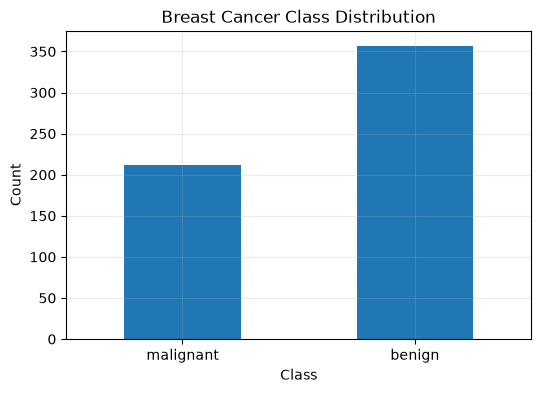

In [80]:
# =========================================================
# PART 3: CLASS DISTRIBUTION
# =========================================================

class_counts = df["target"].value_counts().sort_index()

print("Class Distribution Before SMOTE:")

for class_value, count in class_counts.items():
    print(
        f"{data.target_names[class_value]}: {count}"
    )


plt.figure(figsize=(6, 4))

class_counts.plot(
    kind="bar"
)

plt.title("Breast Cancer Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(
    [0, 1],
    data.target_names,
    rotation=0
)

plt.show()


# The classes are not perfectly balanced:
# malignant has fewer samples than benign.


mean radius
Q1: 11.71
Q3: 15.78
IQR: 4.0699999999999985
Number of Outliers: 14

mean texture
Q1: 16.17
Q3: 21.8
IQR: 5.629999999999999
Number of Outliers: 7


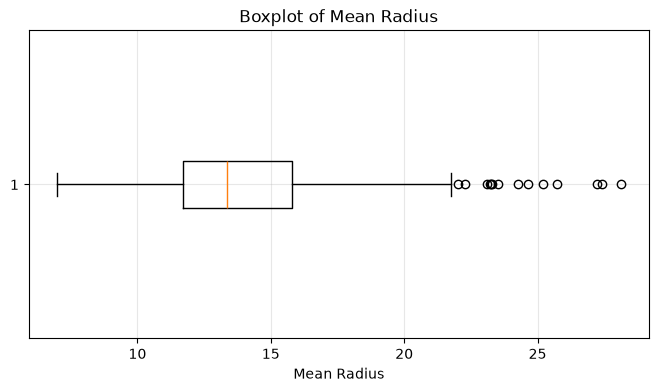

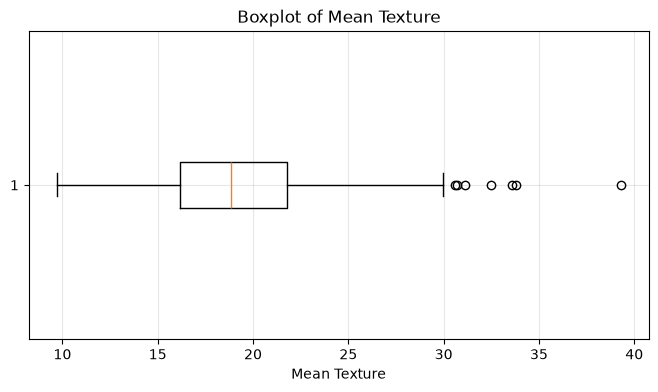

In [81]:
# =========================================================
# PART 4: OUTLIER DETECTION USING IQR
# =========================================================

features_to_check = [
    "mean radius",
    "mean texture"
]

for feature in features_to_check:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower_limit) |
        (df[feature] > upper_limit)
    ]

    print(f"\n{feature}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Number of Outliers:", len(outliers))


# ---------------------------------------------------------
# Boxplots
# ---------------------------------------------------------

plt.figure(figsize=(8, 4))

plt.boxplot(
    df["mean radius"],
    vert=False
)

plt.title("Boxplot of Mean Radius")
plt.xlabel("Mean Radius")
plt.grid(alpha=0.3)

plt.show()


plt.figure(figsize=(8, 4))

plt.boxplot(
    df["mean texture"],
    vert=False
)

plt.title("Boxplot of Mean Texture")
plt.xlabel("Mean Texture")
plt.grid(alpha=0.3)

plt.show()

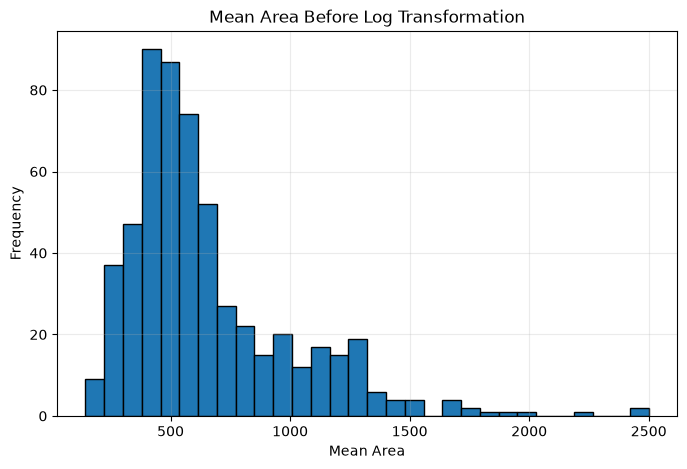

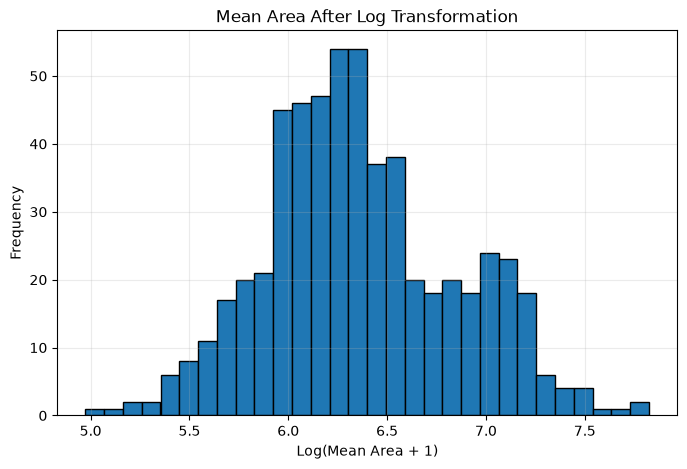

In [82]:
# =========================================================
# PART 5: LOG TRANSFORMATION OF MEAN AREA
# =========================================================

df["mean area log"] = np.log1p(
    df["mean area"]
)


# Distribution before transformation
plt.figure(figsize=(8, 5))

plt.hist(
    df["mean area"],
    bins=30,
    edgecolor="black"
)

plt.title("Mean Area Before Log Transformation")
plt.xlabel("Mean Area")
plt.ylabel("Frequency")

plt.show()


# Distribution after transformation
plt.figure(figsize=(8, 5))

plt.hist(
    df["mean area log"],
    bins=30,
    edgecolor="black"
)

plt.title("Mean Area After Log Transformation")
plt.xlabel("Log(Mean Area + 1)")
plt.ylabel("Frequency")

plt.show()

In [83]:
# =========================================================
# PART 6: FEATURE SCALING
# =========================================================

X = df.drop(
    columns=[
        "target",
        "mean area log"
    ]
)

y = df["target"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Shape After Scaling:")
print(X_scaled.shape)

print(
    "\nStandardScaler gives features comparable scales. "
    "This is important for distance-based methods such as "
    "KNN and for SVM because features with large numerical "
    "ranges could otherwise dominate the model."
)

Shape After Scaling:
(569, 30)

StandardScaler gives features comparable scales. This is important for distance-based methods such as KNN and for SVM because features with large numerical ranges could otherwise dominate the model.


In [84]:
# =========================================================
# PART 7: PCA
# =========================================================

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

pca_df = pd.DataFrame(
    X_pca,
    columns=[
        "PC1",
        "PC2"
    ]
)

pca_df["Target"] = y.values

print("PCA Dataset:")
display(pca_df.head())

print(
    "Explained Variance Ratio:",
    pca.explained_variance_ratio_
)

print(
    "Total Explained Variance:",
    pca.explained_variance_ratio_.sum()
)

PCA Dataset:


,PC1,PC2,Target
0,9.194795,1.942436,0
1,2.387269,-3.769731,0
2,5.734576,-1.078932,0
3,7.127831,10.272775,0
4,3.935674,-1.950508,0


Explained Variance Ratio: [0.44266811 0.18950667]
Total Explained Variance: 0.6321747816376768


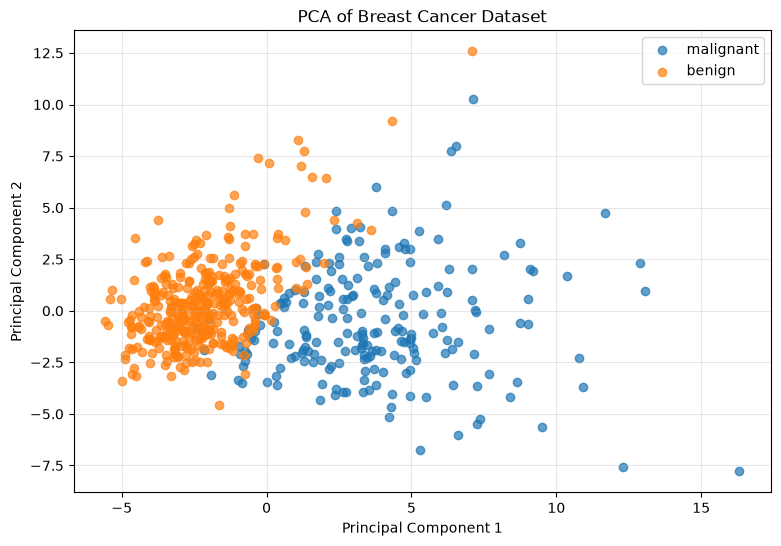

The PCA plot generally shows noticeable separation between malignant and benign samples, although some overlap remains between the two classes.


In [85]:
# =========================================================
# PART 8: PCA SCATTER PLOT
# =========================================================

plt.figure(figsize=(9, 6))

for target_value, target_name in enumerate(
    data.target_names
):

    points = pca_df[
        pca_df["Target"] == target_value
    ]

    plt.scatter(
        points["PC1"],
        points["PC2"],
        label=target_name,
        alpha=0.7
    )

plt.title(
    "PCA of Breast Cancer Dataset"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

print(
    "The PCA plot generally shows noticeable separation "
    "between malignant and benign samples, although some "
    "overlap remains between the two classes."
)

In [86]:
# =========================================================
# PART 9: TRAIN / TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Class Counts Before SMOTE:")
print(y_train.value_counts().sort_index())


# ---------------------------------------------------------
# Scale using training data only
# ---------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

Training Class Counts Before SMOTE:
target
0    170
1    285
Name: count, dtype: int64


In [87]:
# =========================================================
# PART 10: HANDLE CLASS IMBALANCE WITH SMOTE
# =========================================================

smote = SMOTE(
    random_state=42
)

X_train_balanced, y_train_balanced = (
    smote.fit_resample(
        X_train_scaled,
        y_train
    )
)

print("Class Counts Before SMOTE:")
print(y_train.value_counts().sort_index())

print("\nClass Counts After SMOTE:")
print(y_train_balanced.value_counts().sort_index())

Class Counts Before SMOTE:
target
0    170
1    285
Name: count, dtype: int64

Class Counts After SMOTE:
target
0    285
1    285
Name: count, dtype: int64


In [90]:
# =========================================================
# PART 11: CLASSIFIER 1 — SVM
# =========================================================

svm_model = SVC(
    kernel="rbf",
    random_state=42
)

svm_model.fit(
    X_train_balanced,
    y_train_balanced
)

svm_predictions = svm_model.predict(
    X_test_scaled
)

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

print(
    "SVM Accuracy:",
    svm_accuracy
)

SVM Accuracy: 0.9649122807017544


In [91]:
# =========================================================
# PART 12: CLASSIFIER 2 — KNN
# =========================================================

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_balanced,
    y_train_balanced
)

knn_predictions = knn_model.predict(
    X_test_scaled
)

knn_accuracy = accuracy_score(
    y_test,
    knn_predictions
)

print(
    "KNN Accuracy:",
    knn_accuracy
)

KNN Accuracy: 0.9210526315789473


In [92]:
# =========================================================
# PART 13: COMPARE CLASSIFIERS
# =========================================================

results = pd.DataFrame({
    "Classifier": [
        "SVM",
        "KNN"
    ],

    "Accuracy": [
        svm_accuracy,
        knn_accuracy
    ]
})

results = results.sort_values(
    "Accuracy",
    ascending=False
)

print("Classifier Comparison:")
display(results)

best_model = results.iloc[0]

print(
    f"Best classifier: "
    f"{best_model['Classifier']} "
    f"with accuracy "
    f"{best_model['Accuracy']:.4f}"
)

Classifier Comparison:


,Classifier,Accuracy
0,SVM,0.964912
1,KNN,0.921053


Best classifier: SVM with accuracy 0.9649


In [93]:
# =========================================================
# PART 14: FINAL CONCLUSION
# =========================================================

print(
    """
Conclusion:
Feature scaling had one of the biggest impacts because the
dataset contains measurements with very different numerical
ranges. Standardization prevents large-valued features from
dominating distance-based models such as KNN and the SVM
optimization process.

PCA also showed that much of the important information can
be summarized in two components, with visible separation
between malignant and benign samples, although some overlap
still remains.
"""
)


Conclusion:
Feature scaling had one of the biggest impacts because the
dataset contains measurements with very different numerical
ranges. Standardization prevents large-valued features from
dominating distance-based models such as KNN and the SVM
optimization process.

PCA also showed that much of the important information can
be summarized in two components, with visible separation
between malignant and benign samples, although some overlap
still remains.

